In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip -q install idx2numpy tf2onnx

!wget -q https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip
!unzip -q gzip.zip

!gunzip -f gzip/emnist-digits-train-images-idx3-ubyte.gz
!gunzip -f gzip/emnist-digits-train-labels-idx1-ubyte.gz
!gunzip -f gzip/emnist-digits-test-images-idx3-ubyte.gz
!gunzip -f gzip/emnist-digits-test-labels-idx1-ubyte.gz

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 19.2 MB/s eta 0:00:00


In [3]:
import idx2numpy
import numpy as np

X_train = idx2numpy.convert_from_file(
    "gzip/emnist-digits-train-images-idx3-ubyte"
)
y_train = idx2numpy.convert_from_file(
    "gzip/emnist-digits-train-labels-idx1-ubyte"
)

X_test = idx2numpy.convert_from_file(
    "gzip/emnist-digits-test-images-idx3-ubyte"
)
y_test = idx2numpy.convert_from_file(
    "gzip/emnist-digits-test-labels-idx1-ubyte"
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(240000, 28, 28) (240000,)
(40000, 28, 28) (40000,)


In [4]:
import numpy as np

X_train = np.rot90(X_train, k=-1, axes=(1,2))
X_train = np.flip(X_train, axis=2)

X_test = np.rot90(X_test, k=-1, axes=(1,2))
X_test = np.flip(X_test, axis=2)

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

X_train = X_train[...,None]
X_test = X_test[...,None]

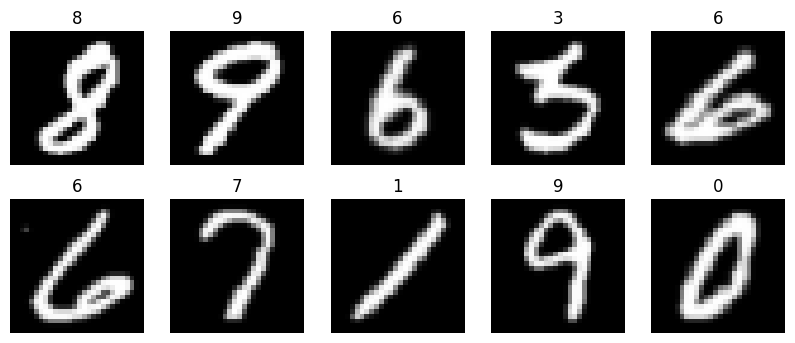

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")

plt.show()

In [6]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Input((28,28,1)),

    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomTranslation(0.08,0.08),
    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.Conv2D(32,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,padding="same",activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256,activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(10,activation="softmax")

])

model.summary()

I0000 00:00:1785748520.364277      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785748520.367197      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )

]

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9609 - loss: 0.1282 - val_accuracy: 0.9926 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9863 - loss: 0.0479 - val_accuracy: 0.9934 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9892 - loss: 0.0379 - val_accuracy: 0.9951 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9907 - loss: 0.0330 - val_accuracy: 0.9943 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9919 - loss: 0.0301 - val_accuracy: 0.9952 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9921 - loss: 0.0281 - val_accuracy: 0.9956 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9

In [10]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9973 - loss: 0.0139
Test Accuracy: 0.9972749948501587


In [11]:
model.save("/kaggle/working/digit_model.keras")

In [12]:
!python -m tf2onnx.convert \
--keras /kaggle/working/digit_model.keras \
--output /kaggle/working/digit_model.onnx

I0000 00:00:1785748742.059343     501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12578 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785748742.061628     501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1785748742.650198     501 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1785748742.650513     501 single_machine.cc:376] Starting new session
I0000 00:00:1785748742.665748     501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12578 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785748742.667457     501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 M

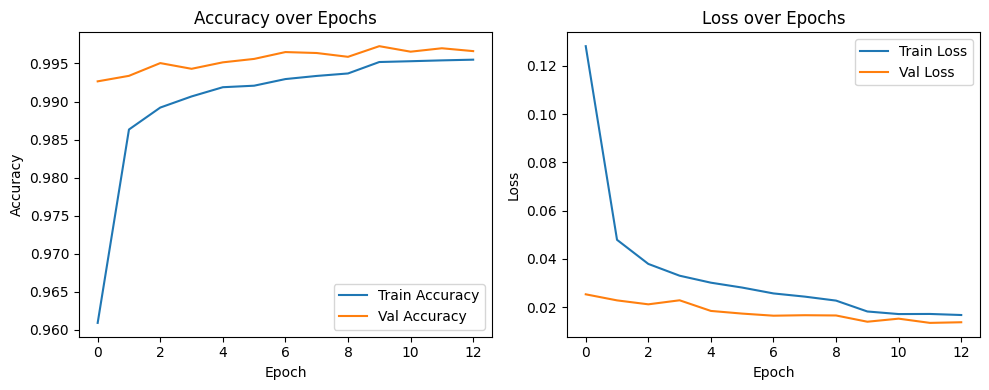

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


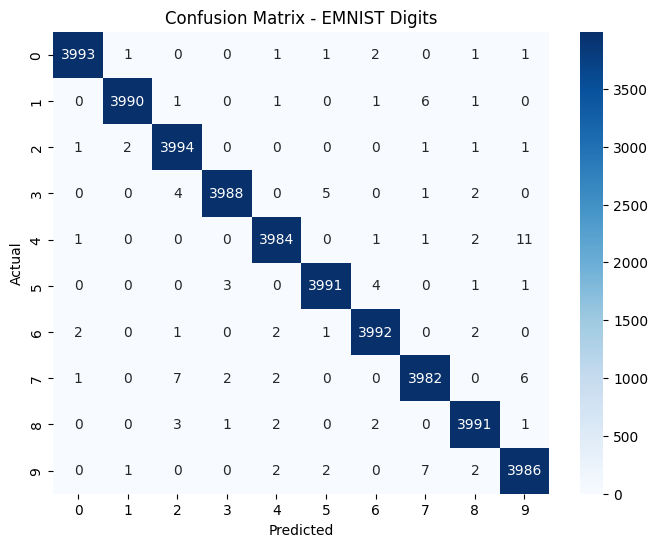

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - EMNIST Digits')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [15]:
import os
print(os.listdir("/kaggle/working"))

['training_curves.png', '__notebook__.ipynb', 'digit_model.keras', 'gzip.zip', 'gzip', 'digit_model.onnx', 'confusion_matrix.png']
